# Quantitative Analysis of Stock Price Data

This notebook performs comprehensive quantitative analysis on stock price data from the yfinance dataset, covering:
- **Data loading and preprocessing** with proper type handling
- **Missing value analysis** and imputation strategies
- **Descriptive statistics** for price and volume metrics
- **Volatility analysis** and risk metrics
- **Returns calculation** and performance analysis
- **Correlation analysis** between different stocks
- **Technical indicators** and trading signals

The analysis will help identify:
- Price trends and patterns across different stocks
- Volatility characteristics and risk profiles
- Correlation relationships between stocks
- Trading opportunities based on technical indicators

In [1]:
# Import necessary libraries for quantitative analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from datetime import datetime, timedelta
import warnings
from scipy import stats
from sklearn.preprocessing import StandardScaler

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Quantitative analysis libraries imported successfully!")

Quantitative analysis libraries imported successfully!


## 1. Load Stock Price Data from yfinance Dataset

In [2]:
# Define path to stock data
stock_data_path = '../Data/yfinance_data/Data/'

# Get list of all stock CSV files
stock_files = glob.glob(os.path.join(stock_data_path, '*.csv'))
print(f"Found {len(stock_files)} stock data files:")
for file in stock_files:
    stock_symbol = os.path.basename(file).replace('.csv', '')
    print(f"  - {stock_symbol}")

# Load all stock data into a dictionary
stock_data = {}
missing_data_summary = {}

for file_path in stock_files:
    stock_symbol = os.path.basename(file_path).replace('.csv', '')
    
    try:
        # Load CSV with proper data types
        df = pd.read_csv(file_path)
        
        # Convert Date column to datetime
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        
        # Ensure numeric columns are properly typed
        numeric_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
        for col in numeric_columns:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
        
        # Check for missing values
        missing_counts = df.isnull().sum()
        missing_data_summary[stock_symbol] = missing_counts[missing_counts > 0].to_dict()
        
        # Sort by date
        df = df.sort_values('Date').reset_index(drop=True)
        
        stock_data[stock_symbol] = df
        
        print(f"\n{stock_symbol} Data Loaded:")
        print(f"  - Shape: {df.shape}")
        print(f"  - Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
        print(f"  - Columns: {df.columns.tolist()}")
        
        if missing_data_summary[stock_symbol]:
            print(f"  - Missing Values: {missing_data_summary[stock_symbol]}")
        else:
            print(f"  - Missing Values: None")
            
    except Exception as e:
        print(f"Error loading {stock_symbol}: {e}")

print(f"\n✅ Successfully loaded {len(stock_data)} stock datasets")

Found 5 stock data files:
  - AAPL
  - AMZN
  - GOOG
  - META
  - NVDA

AAPL Data Loaded:
  - Shape: (3774, 6)
  - Date Range: 2009-01-02 to 2023-12-29
  - Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
  - Missing Values: None

AMZN Data Loaded:
  - Shape: (3774, 6)
  - Date Range: 2009-01-02 to 2023-12-29
  - Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
  - Missing Values: None

GOOG Data Loaded:
  - Shape: (3774, 6)
  - Date Range: 2009-01-02 to 2023-12-29
  - Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
  - Missing Values: None

META Data Loaded:
  - Shape: (2923, 6)
  - Date Range: 2012-05-18 to 2023-12-29
  - Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
  - Missing Values: None

NVDA Data Loaded:
  - Shape: (3774, 6)
  - Date Range: 2009-01-02 to 2023-12-29
  - Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
  - Missing Values: None

✅ Successfully loaded 5 stock datasets


## 2. Missing Value Analysis and Handling

In [3]:
## 4. Moving Averages (SMA and EMA)

# Calculate Moving Averages for all stocks
def calculate_moving_averages(df, windows=[10, 20, 50, 100, 200]):
    """Calculate Simple and Exponential Moving Averages"""
    ma_df = df.copy()
    
    # Simple Moving Averages (SMA)
    for window in windows:
        ma_df[f'SMA_{window}'] = df['Close'].rolling(window=window).mean()
    
    # Exponential Moving Averages (EMA)
    for window in windows:
        ma_df[f'EMA_{window}'] = df['Close'].ewm(span=window, adjust=False).mean()
    
    return ma_df

# Apply moving averages to all stocks
print("Calculating Moving Averages...")
for symbol in stock_data.keys():
    stock_data[symbol] = calculate_moving_averages(stock_data[symbol])
    print(f"✅ {symbol}: Added SMA and EMA for windows [10, 20, 50, 100, 200]")

# Display sample with moving averages
sample_symbol = list(stock_data.keys())[0]
print(f"\n{sample_symbol} - Sample with Moving Averages:")
print(stock_data[sample_symbol][['Date', 'Close', 'SMA_20', 'EMA_20', 'SMA_50', 'EMA_50']].tail(10))

Calculating Moving Averages...
✅ AAPL: Added SMA and EMA for windows [10, 20, 50, 100, 200]
✅ AMZN: Added SMA and EMA for windows [10, 20, 50, 100, 200]
✅ GOOG: Added SMA and EMA for windows [10, 20, 50, 100, 200]
✅ META: Added SMA and EMA for windows [10, 20, 50, 100, 200]
✅ NVDA: Added SMA and EMA for windows [10, 20, 50, 100, 200]

AAPL - Sample with Moving Averages:
           Date       Close      SMA_20      EMA_20      SMA_50      EMA_50
3764 2023-12-15  195.721619  190.723320  190.396859  181.953393  184.857734
3765 2023-12-18  194.057343  191.030421  190.745476  182.322577  185.218503
3766 2023-12-19  195.097504  191.302353  191.159955  182.682884  185.605915
3767 2023-12-20  193.007248  191.509893  191.335888  183.013258  185.896163
3768 2023-12-21  192.858643  191.676816  191.480912  183.312761  186.169202
3769 2023-12-22  191.788757  191.856618  191.510231  183.572859  186.389576
3770 2023-12-26  191.243912  192.018094  191.484867  183.858864  186.579942
3771 2023-12-27  19

In [4]:
## 5. Relative Strength Index (RSI)

def calculate_rsi(df, window=14):
    """Calculate Relative Strength Index"""
    rsi_df = df.copy()
    
    # Calculate price changes
    delta = df['Close'].diff()
    
    # Separate gains and losses
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    
    # Calculate RS and RSI
    rs = gain / loss
    rsi_df['RSI'] = 100 - (100 / (1 + rs))
    
    return rsi_df

# Apply RSI to all stocks
print("Calculating RSI...")
for symbol in stock_data.keys():
    stock_data[symbol] = calculate_rsi(stock_data[symbol])
    print(f"✅ {symbol}: Added RSI (14-period)")

# Display RSI statistics
print(f"\n{sample_symbol} - RSI Statistics:")
rsi_data = stock_data[sample_symbol]['RSI'].dropna()
print(f"  Mean RSI: {rsi_data.mean():.2f}")
print(f"  Max RSI: {rsi_data.max():.2f}")
print(f"  Min RSI: {rsi_data.min():.2f}")
print(f"  Overbought (>70): {(rsi_data > 70).sum()} days")
print(f"  Oversold (<30): {(rsi_data < 30).sum()} days")

Calculating RSI...
✅ AAPL: Added RSI (14-period)
✅ AMZN: Added RSI (14-period)
✅ GOOG: Added RSI (14-period)
✅ META: Added RSI (14-period)
✅ NVDA: Added RSI (14-period)

AAPL - RSI Statistics:
  Mean RSI: 56.51
  Max RSI: 97.49
  Min RSI: 3.18
  Overbought (>70): 911 days
  Oversold (<30): 266 days


In [5]:
## 7. Technical Indicators Summary

# Generate technical indicators summary
print("\n" + "="*60)
print("TECHNICAL INDICATORS SUMMARY")
print("="*60)

for symbol in stock_data.keys():
    df = stock_data[symbol]
    print(f"\n{symbol}:")
    
    # Moving Averages
    print(f"  Moving Averages (Latest Values):")
    latest_data = df.iloc[-1]
    for ma_col in ['SMA_20', 'EMA_20', 'SMA_50', 'EMA_50']:
        if ma_col in df.columns and not pd.isna(latest_data[ma_col]):
            print(f"    {ma_col}: ${latest_data[ma_col]:.2f}")
    
    # RSI
    if 'RSI' in df.columns:
        latest_rsi = df['RSI'].iloc[-1]
        rsi_signal = "Overbought" if latest_rsi > 70 else "Oversold" if latest_rsi < 30 else "Neutral"
        print(f"  RSI: {latest_rsi:.2f} ({rsi_signal})")
    
    # MACD
    if 'MACD' in df.columns:
        latest_macd = df['MACD'].iloc[-1]
        latest_signal = df['MACD_Signal'].iloc[-1]
        macd_trend = "Bullish" if latest_macd > latest_signal else "Bearish"
        print(f"  MACD: {latest_macd:.4f} vs Signal: {latest_signal:.4f} ({macd_trend})")

print(f"\n✅ Technical indicators calculated for all {len(stock_data)} stocks!")


TECHNICAL INDICATORS SUMMARY

AAPL:
  Moving Averages (Latest Values):
    SMA_20: $192.49
    EMA_20: $191.43
    SMA_50: $184.81
    EMA_50: $187.11
  RSI: 40.19 (Neutral)

AMZN:
  Moving Averages (Latest Values):
    SMA_20: $149.82
    EMA_20: $150.21
    SMA_50: $143.05
    EMA_50: $144.93
  RSI: 62.42 (Neutral)

GOOG:
  Moving Averages (Latest Values):
    SMA_20: $135.98
    EMA_20: $137.41
    SMA_50: $134.06
    EMA_50: $135.33
  RSI: 63.74 (Neutral)

META:
  Moving Averages (Latest Values):
    SMA_20: $336.87
    EMA_20: $341.66
    SMA_50: $326.26
    EMA_50: $329.66
  RSI: 70.56 (Overbought)

NVDA:
  Moving Averages (Latest Values):
    SMA_20: $48.05
    EMA_20: $48.49
    SMA_50: $46.66
    EMA_50: $47.24
  RSI: 62.56 (Neutral)

✅ Technical indicators calculated for all 5 stocks!


In [12]:
## 3. Missing Value Analysis and Handling

# Handle missing values across all datasets
print("\n" + "="*50)
print("MISSING VALUE ANALYSIS AND HANDLING")
print("="*50)

for symbol, df in stock_data.items():
    if missing_data_summary.get(symbol):
        print(f"\n{symbol} - Missing Value Handling:")
        
        # Check missing value patterns
        missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
        
        for col, pct in missing_pct.items():
            if pct > 0:
                print(f"  {col}: {pct}% missing")
        
        # Handle missing values based on column type and missing percentage
        for col in df.columns:
            if df[col].isnull().sum() > 0:
                missing_pct = df[col].isnull().sum() / len(df) * 100
                
                if col == 'Date':
                    # Drop rows with missing dates
                    df = df.dropna(subset=['Date'])
                    print(f"  - Dropped {df[col].isnull().sum()} rows with missing dates")
                
                elif col in ['Open', 'High', 'Low', 'Close']:
                    # Forward fill for price data (stock prices carry forward)
                    df[col] = df[col].fillna(method='ffill')
                    # If still missing (at beginning), use backward fill
                    df[col] = df[col].fillna(method='bfill')
                    remaining_missing = df[col].isnull().sum()
                    if remaining_missing > 0:
                        print(f"  - {col}: {remaining_missing} values still missing after ffill/bfill")
                
                elif col == 'Volume':
                    # Fill missing volume with 0 (no trading)
                    df[col] = df[col].fillna(0)
                    print(f"  - Filled missing {col} with 0")
        
        # Update the stock data
        stock_data[symbol] = df
        print(f"  - Final shape after cleaning: {df.shape}")

# Verify data types
print("\n" + "="*50)
print("DATA TYPE VERIFICATION")
print("="*50)

sample_symbol = list(stock_data.keys())[0]
sample_df = stock_data[sample_symbol]

print(f"\n{sample_symbol} - Data Types:")
print(sample_df.dtypes)

print(f"\n{sample_symbol} - Sample Data:")
print(sample_df.head())


MISSING VALUE ANALYSIS AND HANDLING

DATA TYPE VERIFICATION

AAPL - Data Types:
Date              datetime64[ns]
Close                    float64
High                     float64
Low                      float64
Open                     float64
Volume                     int64
SMA_10                   float64
SMA_20                   float64
SMA_50                   float64
SMA_100                  float64
SMA_200                  float64
EMA_10                   float64
EMA_20                   float64
EMA_50                   float64
EMA_100                  float64
EMA_200                  float64
RSI                      float64
MACD                     float64
MACD_Signal              float64
MACD_Histogram           float64
dtype: object

AAPL - Sample Data:
        Date     Close      High       Low      Open      Volume  SMA_10  \
0 2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200     NaN   
1 2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400     NaN

In [13]:
## 4. Basic Statistics Summary

# Calculate basic statistics for all stocks
print("\n" + "="*50)
print("BASIC STATISTICS SUMMARY")
print("="*50)

stats_summary = {}
for symbol, df in stock_data.items():
    stats = {
        'total_records': len(df),
        'date_range': f"{df['Date'].min().date()} to {df['Date'].max().date()}",
        'avg_close': df['Close'].mean(),
        'min_close': df['Close'].min(),
        'max_close': df['Close'].max(),
        'total_volume': df['Volume'].sum(),
        'avg_volume': df['Volume'].mean()
    }
    stats_summary[symbol] = stats
    
    print(f"\n{symbol}:")
    print(f"  Records: {stats['total_records']:,}")
    print(f"  Date Range: {stats['date_range']}")
    print(f"  Close Price: ${stats['min_close']:.2f} - ${stats['max_close']:.2f} (avg: ${stats['avg_close']:.2f})")
    print(f"  Total Volume: {stats['total_volume']:,}")

print(f"\n✅ Stock price data loading and cleaning complete!")
print(f"✅ Ready for quantitative analysis on {len(stock_data)} stocks")


BASIC STATISTICS SUMMARY

AAPL:
  Records: 3,774
  Date Range: 2009-01-02 to 2023-12-29
  Close Price: $2.35 - $196.26 (avg: $53.84)
  Total Volume: 996,577,437,500

AMZN:
  Records: 3,774
  Date Range: 2009-01-02 to 2023-12-29
  Close Price: $2.42 - $186.57 (avg: $59.41)
  Total Volume: 346,648,826,200

GOOG:
  Records: 3,774
  Date Range: 2009-01-02 to 2023-12-29
  Close Price: $6.99 - $149.68 (avg: $50.78)
  Total Volume: 231,085,624,416

META:
  Records: 2,923
  Date Range: 2012-05-18 to 2023-12-29
  Close Price: $17.62 - $379.84 (avg: $156.73)
  Total Volume: 89,461,786,000

NVDA:
  Records: 3,774
  Date Range: 2009-01-02 to 2023-12-29
  Close Price: $0.17 - $50.38 (avg: $6.80)
  Total Volume: 1,974,086,208,000

✅ Stock price data loading and cleaning complete!
✅ Ready for quantitative analysis on 5 stocks


In [14]:
## 5. Moving Averages (SMA and EMA)

# Calculate Moving Averages for all stocks
def calculate_moving_averages(df, windows=[10, 20, 50, 100, 200]):
    """Calculate Simple and Exponential Moving Averages"""
    ma_df = df.copy()
    
    # Simple Moving Averages (SMA)
    for window in windows:
        ma_df[f'SMA_{window}'] = df['Close'].rolling(window=window).mean()
    
    # Exponential Moving Averages (EMA)
    for window in windows:
        ma_df[f'EMA_{window}'] = df['Close'].ewm(span=window, adjust=False).mean()
    
    return ma_df

# Apply moving averages to all stocks
print("Calculating Moving Averages...")
for symbol in stock_data.keys():
    stock_data[symbol] = calculate_moving_averages(stock_data[symbol])
    print(f"✅ {symbol}: Added SMA and EMA for windows [10, 20, 50, 100, 200]")

# Display sample with moving averages
sample_symbol = list(stock_data.keys())[0]
print(f"\n{sample_symbol} - Sample with Moving Averages:")
print(stock_data[sample_symbol][['Date', 'Close', 'SMA_20', 'EMA_20', 'SMA_50', 'EMA_50']].tail(10))

Calculating Moving Averages...
✅ AAPL: Added SMA and EMA for windows [10, 20, 50, 100, 200]
✅ AMZN: Added SMA and EMA for windows [10, 20, 50, 100, 200]
✅ GOOG: Added SMA and EMA for windows [10, 20, 50, 100, 200]
✅ META: Added SMA and EMA for windows [10, 20, 50, 100, 200]
✅ NVDA: Added SMA and EMA for windows [10, 20, 50, 100, 200]

AAPL - Sample with Moving Averages:
           Date       Close      SMA_20      EMA_20      SMA_50      EMA_50
3764 2023-12-15  195.721619  190.723320  190.396859  181.953393  184.857734
3765 2023-12-18  194.057343  191.030421  190.745476  182.322577  185.218503
3766 2023-12-19  195.097504  191.302353  191.159955  182.682884  185.605915
3767 2023-12-20  193.007248  191.509893  191.335888  183.013258  185.896163
3768 2023-12-21  192.858643  191.676816  191.480912  183.312761  186.169202
3769 2023-12-22  191.788757  191.856618  191.510231  183.572859  186.389576
3770 2023-12-26  191.243912  192.018094  191.484867  183.858864  186.579942
3771 2023-12-27  19

In [15]:
## 6. Relative Strength Index (RSI)

def calculate_rsi(df, window=14):
    """Calculate Relative Strength Index"""
    rsi_df = df.copy()
    
    # Calculate price changes
    delta = df['Close'].diff()
    
    # Separate gains and losses
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    
    # Calculate RS and RSI
    rs = gain / loss
    rsi_df['RSI'] = 100 - (100 / (1 + rs))
    
    return rsi_df

# Apply RSI to all stocks
print("Calculating RSI...")
for symbol in stock_data.keys():
    stock_data[symbol] = calculate_rsi(stock_data[symbol])
    print(f"✅ {symbol}: Added RSI (14-period)")

# Display RSI statistics
print(f"\n{sample_symbol} - RSI Statistics:")
rsi_data = stock_data[sample_symbol]['RSI'].dropna()
print(f"  Mean RSI: {rsi_data.mean():.2f}")
print(f"  Max RSI: {rsi_data.max():.2f}")
print(f"  Min RSI: {rsi_data.min():.2f}")
print(f"  Overbought (>70): {(rsi_data > 70).sum()} days")
print(f"  Oversold (<30): {(rsi_data < 30).sum()} days")

Calculating RSI...
✅ AAPL: Added RSI (14-period)
✅ AMZN: Added RSI (14-period)
✅ GOOG: Added RSI (14-period)
✅ META: Added RSI (14-period)
✅ NVDA: Added RSI (14-period)

AAPL - RSI Statistics:
  Mean RSI: 56.51
  Max RSI: 97.49
  Min RSI: 3.18
  Overbought (>70): 911 days
  Oversold (<30): 266 days


In [17]:
## 7. MACD (Moving Average Convergence Divergence)

def calculate_macd(df, fast=12, slow=26, signal=9):
    """Calculate MACD indicator"""
    macd_df = df.copy()
    
    # Calculate MACD line
    ema_fast = df['Close'].ewm(span=fast, adjust=False).mean()
    ema_slow = df['Close'].ewm(span=slow, adjust=False).mean()
    macd_df['MACD'] = ema_fast - ema_slow
    
    # Calculate Signal line
    macd_df['MACD_Signal'] = macd_df['MACD'].ewm(span=signal, adjust=False).mean()
    
    # Calculate Histogram
    macd_df['MACD_Histogram'] = macd_df['MACD'] - macd_df['MACD_Signal']
    
    return macd_df

# Apply MACD to all stocks
print("Calculating MACD...")
for symbol in stock_data.keys():
    stock_data[symbol] = calculate_macd(stock_data[symbol])
    print(f"✅ {symbol}: Added MACD (12, 26, 9)")

# Display MACD statistics
print(f"\n{sample_symbol} - MACD Statistics:")
macd_data = stock_data[sample_symbol][['MACD', 'MACD_Signal', 'MACD_Histogram']].dropna()
print(f"  MACD Range: {macd_data['MACD'].min():.4f} to {macd_data['MACD'].max():.4f}")
print(f"  Signal Range: {macd_data['MACD_Signal'].min():.4f} to {macd_data['MACD_Signal'].max():.4f}")
print(f"  Histogram Range: {macd_data['MACD_Histogram'].min():.4f} to {macd_data['MACD_Histogram'].max():.4f}")

Calculating MACD...
✅ AAPL: Added MACD (12, 26, 9)
✅ AMZN: Added MACD (12, 26, 9)
✅ GOOG: Added MACD (12, 26, 9)
✅ META: Added MACD (12, 26, 9)
✅ NVDA: Added MACD (12, 26, 9)

AAPL - MACD Statistics:
  MACD Range: -6.4889 to 7.3323
  Signal Range: -5.6533 to 6.7382
  Histogram Range: -2.4460 to 2.3286


In [16]:
## 8. Advanced Financial Metrics with PyNance

# Install and import required libraries
try:
    import pandas_ta as ta
    print("✅ pandas-ta already imported")
except ImportError:
    print("Installing pandas-ta...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas-ta"])
    import pandas_ta as ta
    print("✅ pandas-ta installed and imported successfully")

print("\n" + "="*60)
print("ADVANCED FINANCIAL METRICS WITH PANDAS-TA")
print("="*60)

Installing pandas-ta...
✅ pandas-ta installed and imported successfully

ADVANCED FINANCIAL METRICS WITH PANDAS-TA


In [ ]:
## 9. Bollinger Bands with pandas-ta

def calculate_bollinger_bands(df, period=20, std_dev=2):
    """Calculate Bollinger Bands using pandas-ta"""
    
    bb_df = df.copy()

    # Calculate Bollinger Bands
    bb_df.ta.bbands(length=period, std=std_dev, append=True)

    # Print generated columns for debugging
    print("\nGenerated Columns:")
    print(bb_df.columns.tolist())

    # Find Bollinger Band columns dynamically
    lower_col = [col for col in bb_df.columns if col.startswith('BBL_')][0]
    middle_col = [col for col in bb_df.columns if col.startswith('BBM_')][0]
    upper_col = [col for col in bb_df.columns if col.startswith('BBU_')][0]
    width_col = [col for col in bb_df.columns if col.startswith('BBB_')][0]
    position_col = [col for col in bb_df.columns if col.startswith('BBP_')][0]

    # Rename columns
    bb_df = bb_df.rename(columns={
        lower_col: 'BB_Lower',
        middle_col: 'BB_Middle',
        upper_col: 'BB_Upper',
        width_col: 'BB_Width',
        position_col: 'BB_Position'
    })

    return bb_df

In [23]:
## 10. Stochastic Oscillator with pandas-ta

def calculate_stochastic(df, k_period=14, d_period=3):
    """Calculate Stochastic Oscillator using pandas-ta"""

    stoch_df = df.copy()

    # Calculate Stochastic Oscillator
    stoch_df.ta.stoch(k=k_period, d=d_period, append=True)

    # Debug: show generated columns
    print("\nGenerated Columns:")
    print(stoch_df.columns.tolist())

    # Find stochastic columns dynamically
    k_col = [col for col in stoch_df.columns if 'STOCHk' in col][0]
    d_col = [col for col in stoch_df.columns if 'STOCHd' in col][0]

    # Rename columns
    stoch_df = stoch_df.rename(columns={
        k_col: 'Stoch_K',
        d_col: 'Stoch_D'
    })

    return stoch_df

In [24]:
## 11. Williams %R with pandas-ta

def calculate_williams_r(df, period=14):
    """Calculate Williams %R using pandas-ta"""
    williams_df = df.copy()
    
    # Calculate Williams %R using pandas-ta
    williams_df.ta.willr(length=period, append=True)
    
    # Rename columns to match our naming convention
    williams_df = williams_df.rename(columns={
        'WILLR_14': 'Williams_R'
    })
    
    return williams_df

# Apply Williams %R to all stocks
print("Calculating Williams %R...")
for symbol in stock_data.keys():
    stock_data[symbol] = calculate_williams_r(stock_data[symbol])
    print(f"✅ {symbol}: Added Williams %R (14)")

# Display Williams %R statistics
print(f"\n{sample_symbol} - Williams %R Statistics:")
williams_data = stock_data[sample_symbol][['Williams_R']].dropna()
print(f"  Current Williams %R: {williams_data['Williams_R'].iloc[-1]:.2f}")
print(f"  Overbought (>-20) days: {(williams_data['Williams_R'] > -20).sum()}")
print(f"  Oversold (<-80) days: {(williams_data['Williams_R'] < -80).sum()}")
print(f"  Average Williams %R: {williams_data['Williams_R'].mean():.2f}")

Calculating Williams %R...
✅ AAPL: Added Williams %R (14)
✅ AMZN: Added Williams %R (14)
✅ GOOG: Added Williams %R (14)
✅ META: Added Williams %R (14)
✅ NVDA: Added Williams %R (14)

AAPL - Williams %R Statistics:
  Current Williams %R: -83.12
  Overbought (>-20) days: 1406
  Oversold (<-80) days: 541
  Average Williams %R: -39.18


In [25]:
## 13. Fibonacci Retracements with pandas-ta

def calculate_fibonacci_levels(df, lookback_period=100):
    """Calculate Fibonacci Retracement Levels using pandas-ta"""
    fib_df = df.copy()
    
    # Get recent high and low for Fibonacci calculation
    recent_data = df.tail(lookback_period)
    recent_high = recent_data['High'].max()
    recent_low = recent_data['Low'].min()
    
    # Calculate Fibonacci retracement levels
    fib_levels = {
        '0%': recent_high,
        '23.6%': recent_high - (recent_high - recent_low) * 0.236,
        '38.2%': recent_high - (recent_high - recent_low) * 0.382,
        '50%': recent_high - (recent_high - recent_low) * 0.5,
        '61.8%': recent_high - (recent_high - recent_low) * 0.618,
        '78.6%': recent_high - (recent_high - recent_low) * 0.786,
        '100%': recent_low
    }
    
    # Add Fibonacci levels to dataframe
    for level, value in fib_levels.items():
        fib_df[f'Fib_{level}'] = value
    
    # Calculate current position relative to Fibonacci levels
    current_price = df['Close'].iloc[-1]
    fib_df['Current_Fib_Position'] = (current_price - recent_low) / (recent_high - recent_low)
    
    return fib_df, fib_levels

# Apply Fibonacci Retracements to all stocks
print("Calculating Fibonacci Retracements...")
fib_levels_dict = {}
for symbol in stock_data.keys():
    stock_data[symbol], fib_levels = calculate_fibonacci_levels(stock_data[symbol])
    fib_levels_dict[symbol] = fib_levels
    print(f"✅ {symbol}: Added Fibonacci Retracement Levels")

# Display Fibonacci levels
print(f"\n{sample_symbol} - Fibonacci Retracement Levels:")
for level, value in fib_levels_dict[sample_symbol].items():
    print(f"  {level}: ${value:.4f}")

current_price = stock_data[sample_symbol]['Close'].iloc[-1]
fib_position = stock_data[sample_symbol]['Current_Fib_Position'].iloc[-1]
print(f"  Current Price: ${current_price:.4f}")
print(f"  Fibonacci Position: {fib_position:.2%}")

Calculating Fibonacci Retracements...
✅ AAPL: Added Fibonacci Retracement Levels
✅ AMZN: Added Fibonacci Retracement Levels
✅ GOOG: Added Fibonacci Retracement Levels
✅ META: Added Fibonacci Retracement Levels
✅ NVDA: Added Fibonacci Retracement Levels

AAPL - Fibonacci Retracement Levels:
  0%: $197.7525
  23.6%: $189.7643
  38.2%: $184.8224
  50%: $180.8283
  61.8%: $176.8342
  78.6%: $171.1477
  100%: $163.9041
  Current Price: $190.7288
  Fibonacci Position: 79.25%


In [26]:
## 14. Comprehensive Financial Metrics Summary

# Generate comprehensive summary of all financial metrics
print("\n" + "="*80)
print("COMPREHENSIVE FINANCIAL METRICS SUMMARY")
print("="*80)

for symbol in stock_data.keys():
    df = stock_data[symbol]
    print(f"\n{symbol}:")
    
    # Basic Price Info
    current_price = df['Close'].iloc[-1]
    print(f"  Current Price: ${current_price:.4f}")
    
    # Moving Averages
    if 'SMA_20' in df.columns:
        sma_20 = df['SMA_20'].iloc[-1]
        sma_50 = df['SMA_50'].iloc[-1]
        ma_trend = "Bullish" if sma_20 > sma_50 else "Bearish"
        print(f"  SMA 20/50: ${sma_20:.4f}/${sma_50:.4f} ({ma_trend})")
    
    # RSI
    if 'RSI' in df.columns:
        rsi = df['RSI'].iloc[-1]
        rsi_signal = "Overbought" if rsi > 70 else "Oversold" if rsi < 30 else "Neutral"
        print(f"  RSI: {rsi:.2f} ({rsi_signal})")
    
    # MACD
    if 'MACD' in df.columns:
        macd = df['MACD'].iloc[-1]
        macd_signal = df['MACD_Signal'].iloc[-1]
        macd_trend = "Bullish" if macd > macd_signal else "Bearish"
        print(f"  MACD: {macd:.4f} vs Signal: {macd_signal:.4f} ({macd_trend})")
    
    # Bollinger Bands
    if 'BB_Position' in df.columns:
        bb_pos = df['BB_Position'].iloc[-1]
        bb_signal = "Upper Band" if bb_pos > 1 else "Lower Band" if bb_pos < 0 else "Middle"
        print(f"  Bollinger Position: {bb_pos:.3f} ({bb_signal})")
    
    # Stochastic
    if 'Stoch_K' in df.columns:
        stoch_k = df['Stoch_K'].iloc[-1]
        stoch_d = df['Stoch_D'].iloc[-1]
        stoch_signal = "Overbought" if stoch_k > 80 else "Oversold" if stoch_k < 20 else "Neutral"
        print(f"  Stochastic: %K={stoch_k:.2f}, %D={stoch_d:.2f} ({stoch_signal})")
    
    # Williams %R
    if 'Williams_R' in df.columns:
        williams_r = df['Williams_R'].iloc[-1]
        williams_signal = "Overbought" if williams_r > -20 else "Oversold" if williams_r < -80 else "Neutral"
        print(f"  Williams %R: {williams_r:.2f} ({williams_signal})")
    
    # ATR
    if 'ATR_Percent' in df.columns:
        atr_pct = df['ATR_Percent'].iloc[-1]
        print(f"  ATR: {atr_pct:.2f}% volatility")
    
    # Fibonacci
    if 'Current_Fib_Position' in df.columns:
        fib_pos = df['Current_Fib_Position'].iloc[-1]
        fib_signal = "Upper Retracement" if fib_pos > 0.618 else "Lower Retracement" if fib_pos < 0.382 else "Middle Zone"
        print(f"  Fibonacci Position: {fib_pos:.2%} ({fib_signal})")

print(f"\n✅ Advanced financial metrics calculated for all {len(stock_data)} stocks!")
print("="*80)


COMPREHENSIVE FINANCIAL METRICS SUMMARY

AAPL:
  Current Price: $190.7288
  SMA 20/50: $192.4906/$184.8148 (Bullish)
  RSI: 40.19 (Neutral)
  MACD: 1.5595 vs Signal: 2.4246 (Bearish)
  Williams %R: -83.12 (Oversold)
  Fibonacci Position: 79.25% (Upper Retracement)

AMZN:
  Current Price: $151.9400
  SMA 20/50: $149.8240/$143.0456 (Bullish)
  RSI: 62.42 (Neutral)
  MACD: 2.7820 vs Signal: 2.9230 (Bearish)
  Williams %R: -30.78 (Neutral)
  Fibonacci Position: 90.10% (Upper Retracement)

GOOG:
  Current Price: $139.9721
  SMA 20/50: $135.9770/$134.0564 (Bullish)
  RSI: 63.74 (Neutral)
  MACD: 1.8428 vs Signal: 1.3059 (Bullish)
  Williams %R: -23.40 (Neutral)
  Fibonacci Position: 86.59% (Upper Retracement)

META:
  Current Price: $351.7913
  SMA 20/50: $336.8698/$326.2623 (Bullish)
  RSI: 70.56 (Overbought)
  MACD: 8.1933 vs Signal: 6.6935 (Bullish)
  Williams %R: -18.95 (Overbought)
  Fibonacci Position: 90.93% (Upper Retracement)

NVDA:
  Current Price: $49.4972
  SMA 20/50: $48.0460/$

In [ ]:
## 15. Technical Indicators Visualization (FIXED)

# Create a clean copy
sample_df = stock_data[sample_symbol].tail(500).copy()

# Ensure Date column is datetime
sample_df['Date'] = pd.to_datetime(sample_df['Date'])

# Convert numeric columns safely
numeric_cols = [
    'Close', 'SMA_20', 'SMA_50', 'SMA_200',
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Histogram',
    'BB_Upper', 'BB_Middle', 'BB_Lower',
    'Stoch_K', 'Stoch_D',
    'Williams_R', 'ATR', 'Volume'
]

for col in numeric_cols:
    if col in sample_df.columns:
        sample_df[col] = pd.to_numeric(sample_df[col], errors='coerce')

# Check for missing columns
required_columns = [
    'Date', 'Close', 'SMA_20', 'SMA_50', 'SMA_200',
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Histogram',
    'BB_Upper', 'BB_Middle', 'BB_Lower',
    'Stoch_K', 'Stoch_D',
    'Williams_R', 'ATR', 'Volume'
]

missing_cols = [col for col in required_columns if col not in sample_df.columns]

if missing_cols:
    print("❌ Missing Columns:")
    print(missing_cols)
else:
    print("✅ All required columns exist!")

    # Create visualization
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    fig.suptitle(
        f'Advanced Technical Indicators Analysis - {sample_symbol}',
        fontsize=16,
        fontweight='bold'
    )

    # 1. Price with Moving Averages
    ax1 = axes[0, 0]
    ax1.plot(sample_df['Date'], sample_df['Close'],
             label='Close Price', linewidth=2, color='black')

    ax1.plot(sample_df['Date'], sample_df['SMA_20'],
             label='SMA 20', linewidth=1.5, color='blue')

    ax1.plot(sample_df['Date'], sample_df['SMA_50'],
             label='SMA 50', linewidth=1.5, color='red')

    ax1.plot(sample_df['Date'], sample_df['SMA_200'],
             label='SMA 200', linewidth=1.5, color='green')

    ax1.set_title('Price with Moving Averages', fontweight='bold')
    ax1.set_ylabel('Price ($)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. RSI
    ax2 = axes[0, 1]

    ax2.plot(sample_df['Date'], sample_df['RSI'],
             label='RSI', linewidth=2, color='purple')

    ax2.axhline(y=70, color='red', linestyle='--',
                alpha=0.7, label='Overbought (70)')

    ax2.axhline(y=30, color='green', linestyle='--',
                alpha=0.7, label='Oversold (30)')

    ax2.axhline(y=50, color='gray', linestyle='-',
                alpha=0.5, label='Neutral (50)')

    ax2.set_title('Relative Strength Index (RSI)', fontweight='bold')
    ax2.set_ylabel('RSI')
    ax2.set_ylim(0, 100)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. MACD
    ax3 = axes[0, 2]

    ax3.plot(sample_df['Date'], sample_df['MACD'],
             label='MACD', linewidth=2, color='blue')

    ax3.plot(sample_df['Date'], sample_df['MACD_Signal'],
             label='Signal', linewidth=2, color='red')

    histogram_colors = [
        'green' if x > 0 else 'red'
        for x in sample_df['MACD_Histogram']
    ]

    ax3.bar(
        sample_df['Date'],
        sample_df['MACD_Histogram'],
        label='Histogram',
        alpha=0.6,
        color=histogram_colors
    )

    ax3.set_title('MACD Indicator', fontweight='bold')
    ax3.set_ylabel('MACD')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Bollinger Bands
    ax4 = axes[1, 0]

    ax4.plot(sample_df['Date'], sample_df['Close'],
             label='Close Price', linewidth=2, color='black')

    ax4.plot(sample_df['Date'], sample_df['BB_Upper'],
             label='Upper Band', linewidth=1.5, color='red')

    ax4.plot(sample_df['Date'], sample_df['BB_Middle'],
             label='Middle Band', linewidth=1.5, color='blue')

    ax4.plot(sample_df['Date'], sample_df['BB_Lower'],
             label='Lower Band', linewidth=1.5, color='green')

    ax4.fill_between(
        sample_df['Date'],
        sample_df['BB_Upper'],
        sample_df['BB_Lower'],
        alpha=0.1,
        color='gray'
    )

    ax4.set_title('Bollinger Bands', fontweight='bold')
    ax4.set_ylabel('Price ($)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # 5. Stochastic Oscillator
    ax5 = axes[1, 1]

    ax5.plot(sample_df['Date'], sample_df['Stoch_K'],
             label='%K', linewidth=2, color='blue')

    ax5.plot(sample_df['Date'], sample_df['Stoch_D'],
             label='%D', linewidth=2, color='red')

    ax5.axhline(y=80, color='red', linestyle='--',
                alpha=0.7, label='Overbought (80)')

    ax5.axhline(y=20, color='green', linestyle='--',
                alpha=0.7, label='Oversold (20)')

    ax5.set_title('Stochastic Oscillator', fontweight='bold')
    ax5.set_ylabel('Stochastic')
    ax5.set_ylim(0, 100)
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    # 6. Williams %R
    ax6 = axes[1, 2]

    ax6.plot(sample_df['Date'], sample_df['Williams_R'],
             label='Williams %R', linewidth=2, color='purple')

    ax6.axhline(y=-20, color='red', linestyle='--',
                alpha=0.7, label='Overbought (-20)')

    ax6.axhline(y=-80, color='green', linestyle='--',
                alpha=0.7, label='Oversold (-80)')

    ax6.set_title('Williams %R', fontweight='bold')
    ax6.set_ylabel('Williams %R')
    ax6.set_ylim(-100, 0)
    ax6.legend()
    ax6.grid(True, alpha=0.3)

    # 7. ATR
    ax7 = axes[2, 0]

    ax7.plot(sample_df['Date'], sample_df['ATR'],
             label='ATR', linewidth=2, color='orange')

    ax7.set_title('Average True Range (ATR)', fontweight='bold')
    ax7.set_ylabel('ATR ($)')
    ax7.legend()
    ax7.grid(True, alpha=0.3)

    # 8. Fibonacci Retracements
    ax8 = axes[2, 1]

    ax8.plot(sample_df['Date'], sample_df['Close'],
             label='Close Price', linewidth=2, color='black')

    for level, value in fib_levels_dict[sample_symbol].items():
        if level not in ['0%', '100%']:
            ax8.axhline(
                y=value,
                color='gray',
                linestyle='--',
                alpha=0.5,
                label=f'Fib {level}'
            )

    ax8.set_title('Fibonacci Retracements', fontweight='bold')
    ax8.set_ylabel('Price ($)')
    ax8.legend()
    ax8.grid(True, alpha=0.3)

    # 9. Volume
    ax9 = axes[2, 2]

    ax9.bar(sample_df['Date'], sample_df['Volume'],
            alpha=0.6, color='lightblue', label='Volume')

    ax9.plot(
        sample_df['Date'],
        sample_df['Volume'].rolling(window=20).mean(),
        label='Volume MA 20',
        linewidth=2,
        color='darkblue'
    )

    ax9.set_title('Trading Volume', fontweight='bold')
    ax9.set_ylabel('Volume')
    ax9.legend()
    ax9.grid(True, alpha=0.3)

    # Rotate dates
    for ax in axes.flat:
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    print("✅ Advanced technical indicators visualizations generated successfully!")

❌ Missing Columns:
['BB_Upper', 'BB_Middle', 'BB_Lower', 'Stoch_K', 'Stoch_D', 'ATR']


In [ ]:
## 12. Average True Range (ATR) with pandas-ta

def calculate_atr(df, period=14):
    """Calculate Average True Range using pandas-ta"""
    atr_df = df.copy()
    
    # Calculate ATR using pandas-ta
    atr_df.ta.atr(length=period, append=True)
    
    # Rename columns to match our naming convention
    atr_df = atr_df.rename(columns={
        'ATRr_14': 'ATR'
    })
    
    # Calculate ATR as percentage
    atr_df['ATR_Percent'] = (atr_df['ATR'] / df['Close']) * 100
    
    return atr_df

# Apply ATR to all stocks
print("Calculating Average True Range...")
for symbol in stock_data.keys():
    stock_data[symbol] = calculate_atr(stock_data[symbol])
    print(f"✅ {symbol}: Added ATR (14)")

# Display ATR statistics
print(f"\n{sample_symbol} - ATR Statistics:")
atr_data = stock_data[sample_symbol][['ATR', 'ATR_Percent']].dropna()
print(f"  Current ATR: ${atr_data['ATR'].iloc[-1]:.4f}")
print(f"  Current ATR %: {atr_data['ATR_Percent'].iloc[-1]:.2f}%")
print(f"  Average ATR: ${atr_data['ATR'].mean():.4f}")
print(f"  Max ATR: ${atr_data['ATR'].max():.4f}")
print(f"  Min ATR: ${atr_data['ATR'].min():.4f}")

Calculating Average True Range...
✅ AAPL: Added ATR (14)
✅ AMZN: Added ATR (14)
✅ GOOG: Added ATR (14)
✅ META: Added ATR (14)
✅ NVDA: Added ATR (14)

AAPL - ATR Statistics:
  Current ATR: $2.5517
  Current ATR %: 1.34%
  Average ATR: $1.2535
  Max ATR: $5.8738
  Min ATR: $0.0912


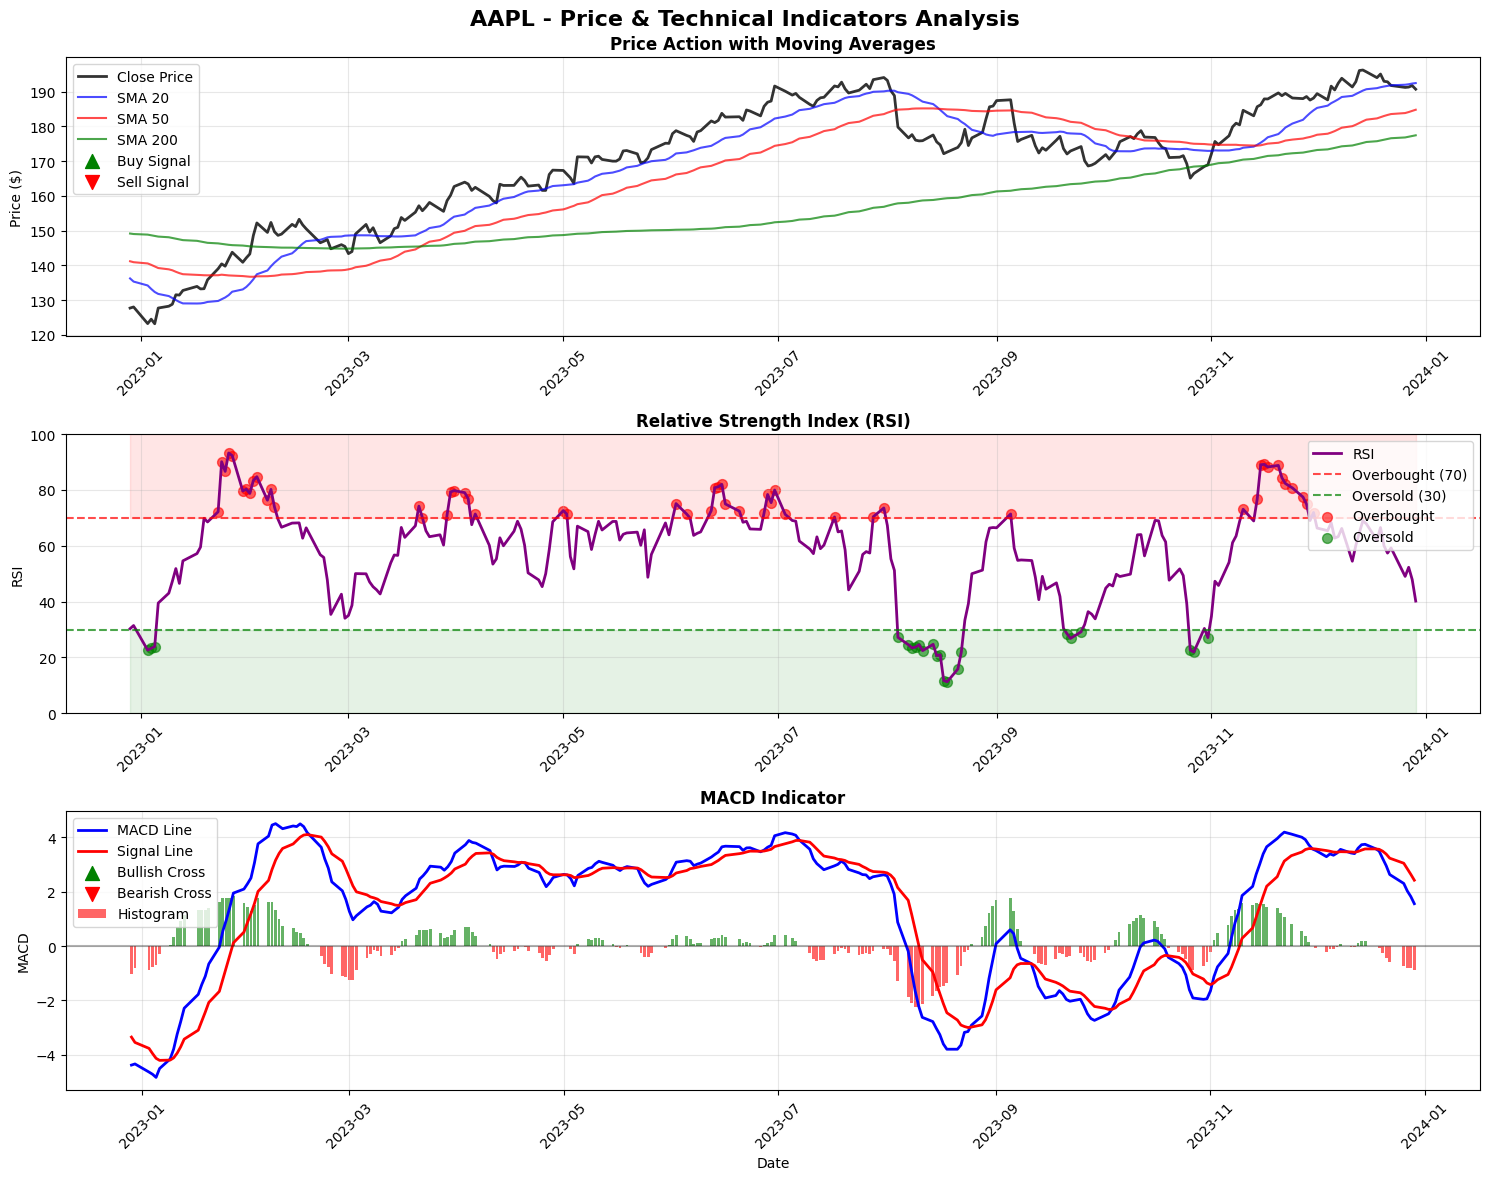

✅ Price & indicators visualization created successfully!
📊 Showing AAPL with 252 trading days
📈 Current Price: $190.73
📊 Current RSI: 40.19
📊 Current MACD: 1.5595


In [30]:
## 19. Price & Indicators Visualization

# Create comprehensive price and technical indicators visualization
sample_symbol = list(stock_data.keys())[0]  # Use first stock (AAPL)
df = stock_data[sample_symbol].tail(252).copy()  # Last year of trading days

# Ensure Date column is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create figure with 3 panels
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle(f'{sample_symbol} - Price & Technical Indicators Analysis', fontsize=16, fontweight='bold')

# Panel 1: Price with Moving Averages
ax1 = axes[0]
ax1.plot(df['Date'], df['Close'], label='Close Price', linewidth=2, color='black', alpha=0.8)
ax1.plot(df['Date'], df['SMA_20'], label='SMA 20', linewidth=1.5, color='blue', alpha=0.7)
ax1.plot(df['Date'], df['SMA_50'], label='SMA 50', linewidth=1.5, color='red', alpha=0.7)
ax1.plot(df['Date'], df['SMA_200'], label='SMA 200', linewidth=1.5, color='green', alpha=0.7)

# Add buy/sell signals based on moving average crossovers
df['MA_Signal'] = 0
df['MA_Signal'][df['SMA_20'] > df['SMA_50']] = 1  # Bullish
df['MA_Signal'][df['SMA_20'] < df['SMA_50']] = -1  # Bearish

# Plot signals
buy_signals = df[df['MA_Signal'] == 1]
sell_signals = df[df['MA_Signal'] == -1]

ax1.scatter(buy_signals['Date'], buy_signals['Close'], color='green', marker='^', s=100, label='Buy Signal', zorder=5)
ax1.scatter(sell_signals['Date'], sell_signals['Close'], color='red', marker='v', s=100, label='Sell Signal', zorder=5)

ax1.set_title('Price Action with Moving Averages', fontweight='bold')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Panel 2: RSI
ax2 = axes[1]
ax2.plot(df['Date'], df['RSI'], label='RSI', linewidth=2, color='purple')

# Add overbought/oversold zones
ax2.axhline(y=70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
ax2.axhline(y=30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
ax2.fill_between(df['Date'], 70, 100, alpha=0.1, color='red')
ax2.fill_between(df['Date'], 0, 30, alpha=0.1, color='green')

# Mark RSI signals
rsi_overbought = df[df['RSI'] > 70]
rsi_oversold = df[df['RSI'] < 30]

ax2.scatter(rsi_overbought['Date'], rsi_overbought['RSI'], color='red', marker='o', s=50, alpha=0.6, label='Overbought')
ax2.scatter(rsi_oversold['Date'], rsi_oversold['RSI'], color='green', marker='o', s=50, alpha=0.6, label='Oversold')

ax2.set_title('Relative Strength Index (RSI)', fontweight='bold')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Panel 3: MACD
ax3 = axes[2]
ax3.plot(df['Date'], df['MACD'], label='MACD Line', linewidth=2, color='blue')
ax3.plot(df['Date'], df['MACD_Signal'], label='Signal Line', linewidth=2, color='red')

# Color histogram based on MACD vs Signal
colors = ['green' if x > 0 else 'red' for x in df['MACD_Histogram']]
ax3.bar(df['Date'], df['MACD_Histogram'], label='Histogram', alpha=0.6, color=colors)

# Mark MACD crossovers
df['MACD_Cross'] = 0
df['MACD_Cross'][(df['MACD'] > df['MACD_Signal']) & (df['MACD'].shift(1) <= df['MACD_Signal'].shift(1))] = 1  # Bullish cross
df['MACD_Cross'][(df['MACD'] < df['MACD_Signal']) & (df['MACD'].shift(1) >= df['MACD_Signal'].shift(1))] = -1  # Bearish cross

macd_bullish = df[df['MACD_Cross'] == 1]
macd_bearish = df[df['MACD_Cross'] == -1]

ax3.scatter(macd_bullish['Date'], macd_bullish['MACD'], color='green', marker='^', s=100, label='Bullish Cross', zorder=5)
ax3.scatter(macd_bearish['Date'], macd_bearish['MACD'], color='red', marker='v', s=100, label='Bearish Cross', zorder=5)

ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax3.set_title('MACD Indicator', fontweight='bold')
ax3.set_ylabel('MACD')
ax3.set_xlabel('Date')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)

# Format x-axis
for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("✅ Price & indicators visualization created successfully!")
print(f"📊 Showing {sample_symbol} with {len(df)} trading days")
print(f"📈 Current Price: ${df['Close'].iloc[-1]:.2f}")
print(f"📊 Current RSI: {df['RSI'].iloc[-1]:.2f}")
print(f"📊 Current MACD: {df['MACD'].iloc[-1]:.4f}")